In [27]:
from dotenv import load_dotenv
import os
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.graph_objects as go

In [17]:
load_dotenv()

db_user = os.getenv('DB_USER')
db_pass = os.getenv('DB_PASS')
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')

engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}")

In [18]:
# dataframe for games, players
df_games = pd.read_sql("SELECT * FROM games", engine)
df_players = pd.read_sql('SELECT * FROM players', engine)
df_player_games = pd.read_sql('SELECT * FROM player_game_stats', engine)
df_teams = pd.read_sql('SELECT * FROM teams', engine)
print(df_players.head(10))
print(df_player_game_stats.head(10))
print(df_teams.head(10))

      id         full_name  birth_date  height_cm  weight_kg  afltables_id  \
0  34104    Lindsay Gilbee  1981-07-08      180.0       83.0           NaN   
1  34221   Domenic Cassisi  1982-09-22      184.0       82.0           NaN   
2  34222    Martin Mattner  1982-08-06      189.0       86.0           NaN   
3  34225      Brent Reilly  1983-11-12      183.0       85.0           NaN   
4  34234        Brian Lake  1982-02-27      195.0       98.0           NaN   
5  34238         Luke Ball  1984-05-25      184.0       83.0           NaN   
6  34241      Daniel Wells  1985-02-03      181.0       79.0           NaN   
7  34245    Adam Schneider  1984-05-12      175.0       79.0           NaN   
8  34246      Jarrad Waite  1983-02-04      194.0       96.0           NaN   
9  34247  Aaron Sandilands  1982-12-06      211.0      118.0           NaN   

   position   kaggle_id  
0  defender  2001717234  
1  midfield  2002679320  
2  defender  2002774605  
3  defender  2002824246  
4  defender

In [19]:
# Check nulls and data coverage
print(df_games[['rainfall', 'max_temp', 'min_temp']].isnull().sum())
print(df_games[['rainfall', 'max_temp', 'min_temp']].describe())
df_games['rain_game'] = df_games['rainfall'] > 0.1
print(df_games['rain_game'].value_counts())

rainfall    475
max_temp    459
min_temp    459
dtype: int64
          rainfall     max_temp     min_temp
count  2640.000000  2656.000000  2656.000000
mean      2.115492    19.159563     9.786069
std       6.319302     5.034669     4.524560
min       0.000000     8.700000    -5.400000
25%       0.000000    15.100000     6.800000
50%       0.000000    18.450000     9.400000
75%       1.450000    22.700000    12.700000
max     114.400000    37.600000    25.000000
rain_game
False    1955
True     1160
Name: count, dtype: int64


In [20]:
# Create ability to compare heights
# Step 1: Keep only games with Kaggle weather data
df_games_weather = df_games[df_games['kaggle_data'] == True].copy()

# Step 2: Merge player_games with players to get player heights
player_games_with_height = df_player_games.merge(
    df_players[['id', 'height_cm']],
    left_on='player_id', right_on='id', how='left'
)

# Step 3: Calculate average team height per game
team_game_heights = (
    player_games_with_height
    .groupby(['game_id', 'team_id'])['height_cm']
    .mean()
    .reset_index()
    .rename(columns={'height_cm': 'avg_team_height'})
)

# Step 4: Merge home and away average heights into weather-enabled games
games_with_height = df_games_weather.merge(
    team_game_heights,
    left_on=['id', 'home_team_id'],
    right_on=['game_id', 'team_id'],
    how='left'
).rename(columns={'avg_team_height': 'home_avg_height'}).drop(['game_id', 'team_id'], axis=1)

games_with_height = games_with_height.merge(
    team_game_heights,
    left_on=['id', 'away_team_id'],
    right_on=['game_id', 'team_id'],
    how='left'
).rename(columns={'avg_team_height': 'away_avg_height'}).drop(['game_id', 'team_id'], axis=1)

# Step 5: Create height difference and taller team flag
games_with_height['height_diff'] = games_with_height['home_avg_height'] - games_with_height['away_avg_height']
games_with_height['taller_team_flag'] = games_with_height['height_diff'].apply(
    lambda x: 1 if x > 0 else (-1 if x < 0 else 0)
)

# Step 6: Flag which team won
games_with_height['home_team_win'] = games_with_height['home_score_total'] > games_with_height['away_score_total']

# Step 7: Did the taller team win? (bool)
games_with_height['taller_team_win'] = (
    ((games_with_height['height_diff'] > 0) & (games_with_height['home_team_win'])) |
    ((games_with_height['height_diff'] < 0) & (~games_with_height['home_team_win']))
)

# Step 8: Create rain flag (use threshold of 0.1mm)
games_with_height['rain_game'] = games_with_height['rainfall'] > 0.1

# Step 9: Check for NaNs (fail if critical)
assert games_with_height['home_avg_height'].notnull().all(), "Missing home team heights!"
assert games_with_height['away_avg_height'].notnull().all(), "Missing away team heights!"
assert games_with_height['height_diff'].notnull().all(), "Missing height difference!"

In [21]:
# How does the taller team go?
rain_crosstab = games_with_height.groupby('rain_game')['taller_team_win'].agg(['mean', 'count'])
print(rain_crosstab)

               mean  count
rain_game                 
False      0.477941   1496
True       0.464655   1160


In [24]:
# binary regression
games_with_height['taller_team_win'] = games_with_height['taller_team_win'].astype(int)
model_binary = smf.logit(
    'taller_team_win ~ height_diff + rain_game + height_diff:rain_game',
    data=games_with_height
).fit()
print(model_binary.summary())

Optimization terminated successfully.
         Current function value: 0.683490
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        taller_team_win   No. Observations:                 2656
Model:                          Logit   Df Residuals:                     2652
Method:                           MLE   Df Model:                            3
Date:                Wed, 28 May 2025   Pseudo R-squ.:                 0.01172
Time:                        00:44:13   Log-Likelihood:                -1815.3
converged:                       True   LL-Null:                       -1836.9
Covariance Type:            nonrobust   LLR p-value:                 2.402e-09
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -0.0952      0.052     -1.819      0.

In [ ]:
# continous
model_continuous = smf.logit(
    'taller_team_win ~ height_diff + rainfall + height_diff:rainfall',
    data=games_with_height
).fit()
print(model_continuous.summary())

Optimization terminated successfully.
         Current function value: 0.683493
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:        taller_team_win   No. Observations:                 2640
Model:                          Logit   Df Residuals:                     2636
Method:                           MLE   Df Model:                            3
Date:                Wed, 28 May 2025   Pseudo R-squ.:                 0.01204
Time:                        00:44:16   Log-Likelihood:                -1804.4
converged:                       True   LL-Null:                       -1826.4
Covariance Type:            nonrobust   LLR p-value:                 1.536e-09
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.0980      0.042     -2.357      0.018      -0.179      -0.017

C:\Users\josep\AppData\Local\Temp\ipykernel_34676\2117522539.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rain_margins = games_with_height.groupby('rain_game').apply(


rain_game
False    34.212567
True     32.357759
dtype: float64


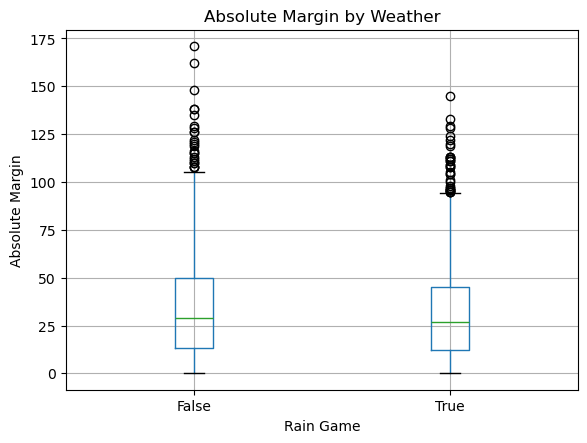

                                       OLS Regression Results                                       
Dep. Variable:     abs(home_score_total - away_score_total)   R-squared:                       0.001
Model:                                                  OLS   Adj. R-squared:                  0.001
Method:                                       Least Squares   F-statistic:                     3.205
Date:                                      Wed, 28 May 2025   Prob (F-statistic):             0.0735
Time:                                              01:47:40   Log-Likelihood:                -12470.
No. Observations:                                      2656   AIC:                         2.494e+04
Df Residuals:                                          2654   BIC:                         2.496e+04
Df Model:                                                 1                                         
Covariance Type:                                  nonrobust                                

In [28]:
rain_margins = games_with_height.groupby('rain_game').apply(
    lambda df: (df['home_score_total'] - df['away_score_total']).abs().mean()
)
print(rain_margins)

games_with_height['margin'] = (games_with_height['home_score_total'] - games_with_height['away_score_total']).abs()
games_with_height.boxplot(column='margin', by='rain_game')
plt.title('Absolute Margin by Weather')
plt.suptitle('')
plt.xlabel('Rain Game')
plt.ylabel('Absolute Margin')
plt.show()

model_margin = smf.ols(
    'abs(home_score_total - away_score_total) ~ rain_game',
    data=games_with_height
).fit()
print(model_margin.summary())
rain_margins = games_with_height.loc[games_with_height['rain_game'], 'margin']
dry_margins = games_with_height.loc[~games_with_height['rain_game'], 'margin']

In [30]:
stats = {}

for label, group in games_with_height.groupby('rain_game'):
    margins = (group['home_score_total'] - group['away_score_total']).abs().dropna()
    margins = np.array(margins)
    q1 = np.percentile(margins, 25)
    median = np.percentile(margins, 50)
    q3 = np.percentile(margins, 75)
    mean = margins.mean()
    min_whisker = margins[margins >= q1 - 1.5 * (q3 - q1)].min()
    max_whisker = margins[margins <= q3 + 1.5 * (q3 - q1)].max()
    stats[str(label)] = dict(
        q1=q1,
        median=median,
        q3=q3,
        mean=mean,
        min=min_whisker,
        max=max_whisker
    )

print(stats)

{'False': {'q1': 13.0, 'median': 29.0, 'q3': 50.0, 'mean': 34.212566844919785, 'min': 0, 'max': 105}, 'True': {'q1': 12.0, 'median': 27.0, 'q3': 45.0, 'mean': 32.35775862068966, 'min': 0, 'max': 94}}
